# 4-1 비선형성과 활성화 함수 필요성

강의 원문 대신 직접 작성하고 실행한 코드와 학습 메모를 정리했습니다.


In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)


In [14]:
# 필수 1. 선형층만 쌓았을 때와 ReLU를 넣었을 때 출력 비교
x = torch.linspace(-3, 3, steps=7).unsqueeze(1)
linear = nn.Linear(1, 1)
linear_only = linear(x)
with_relu = torch.relu(linear(x))
print('x:', x.squeeze().tolist())
print('linear_only:', linear_only.squeeze().detach().round(decimals=3).tolist())
print('with_relu:', with_relu.squeeze().detach().round(decimals=3).tolist())
print(linear_only.shape)
print(with_relu.shape)



x: [-3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0]
linear_only: [-3.378000020980835, -2.496999979019165, -1.6150000095367432, -0.734000027179718, 0.14800000190734863, 1.0290000438690186, 1.9110000133514404]
with_relu: [0.0, 0.0, 0.0, 0.0, 0.14800000190734863, 1.0290000438690186, 1.9110000133514404]
torch.Size([7, 1])
torch.Size([7, 1])


In [6]:
# 필수 2. XOR 데이터가 선형 경계로 어려운 이유 관찰
xor_x = torch.tensor([[0.,0.], [0.,1.], [1.,0.], [1.,1.]])
xor_y = torch.tensor([0, 1, 1, 0])
print('XOR data:')
for x_i, y_i in zip(xor_x, xor_y):
    print(x_i.tolist(), '->', int(y_i))


XOR data:
[0.0, 0.0] -> 0
[0.0, 1.0] -> 1
[1.0, 0.0] -> 1
[1.0, 1.0] -> 0


In [17]:
# 심화 1. 비선형 feature를 추가하면 XOR도 분리 가능해집니다.
nonlinear_feature = (xor_x[:, 0] * xor_x[:, 1]).unsqueeze(1)
expanded = torch.cat([xor_x, nonlinear_feature], dim=1)
print('expanded features:', expanded)
assert expanded.shape == (4, 3)


expanded features: tensor([[0., 0., 0.],
        [0., 1., 0.],
        [1., 0., 0.],
        [1., 1., 1.]])


/tmp/ipykernel_870/2742403327.py:57: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_870/2742403327.py:57: UserWarning: Glyph 46412 (\N{HANGUL SYLLABLE DDAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46412 (\N{HANGUL SYLLABLE DDAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


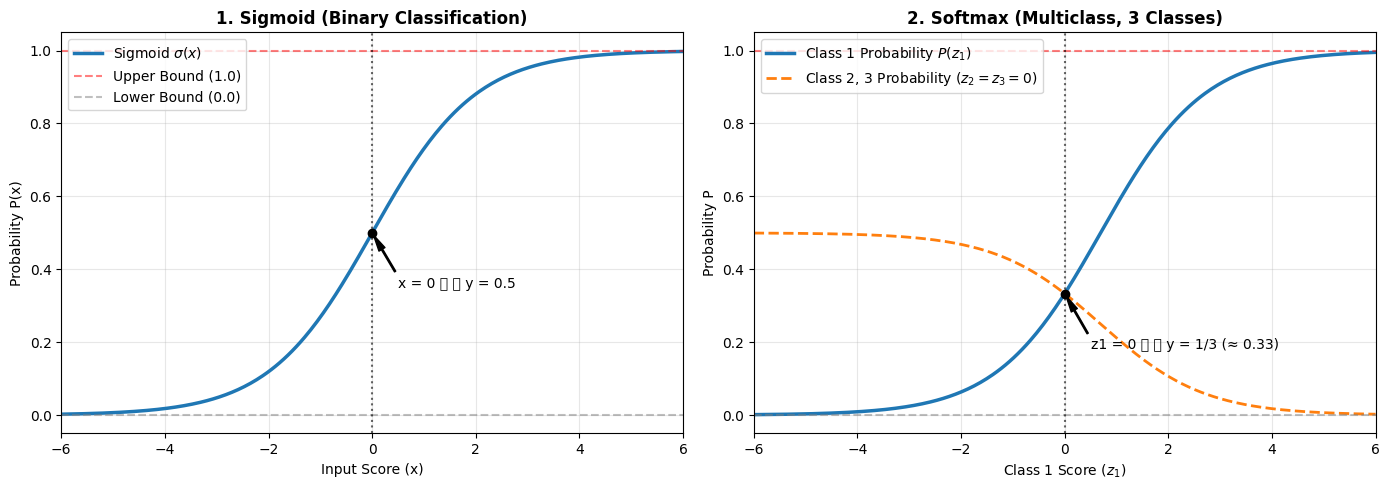

In [8]:
# sigmoid와 softmax의 시각적인 그래프 차이



import numpy as np
import matplotlib.pyplot as plt

# 1. 입력 X축 (점수/Logit Range: -6부터 +6까지)
x = np.linspace(-6, 6, 300)

# 2. Sigmoid 계산
sigmoid_y = 1 / (1 + np.exp(-x))

# 3. Softmax 계산 (클래스가 3개이고, 다른 두 클래스의 점수가 0으로 고정되어 있다고 가정)
# P1(z1) = exp(z1) / (exp(z1) + exp(0) + exp(0))
softmax_p1 = np.exp(x) / (np.exp(x) + np.exp(0) + np.exp(0))
softmax_p2 = np.exp(0) / (np.exp(x) + np.exp(0) + np.exp(0)) # 상대 클래스 확률

# 그래프 그리기
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- [좌] Sigmoid 올바른 그래프 ---
axes[0].plot(x, sigmoid_y, color='#1f77b4', linewidth=2.5, label=r'Sigmoid $\sigma(x)$')
axes[0].axhline(1.0, color='red', linestyle='--', alpha=0.5, label='Upper Bound (1.0)')
axes[0].axhline(0.0, color='gray', linestyle='--', alpha=0.5, label='Lower Bound (0.0)')
axes[0].axvline(0.0, color='black', linestyle=':', alpha=0.6)
axes[0].scatter([0], [0.5], color='black', zorder=5)
axes[0].annotate('x = 0 일 때 y = 0.5', xy=(0, 0.5), xytext=(0.5, 0.35),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))

axes[0].set_title('1. Sigmoid (Binary Classification)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Input Score (x)')
axes[0].set_ylabel('Probability P(x)')
axes[0].set_xlim(-6, 6)
axes[0].set_ylim(-0.05, 1.05)
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc='upper left')

# --- [우] Softmax 올바른 그래프 ---
axes[1].plot(x, softmax_p1, color='#1f77b4', linewidth=2.5, label=r'Class 1 Probability $P(z_1)$')
axes[1].plot(x, softmax_p2, color='#ff7f0e', linestyle='--', linewidth=2, label=r'Class 2, 3 Probability ($z_2=z_3=0$)')
axes[1].axhline(1.0, color='red', linestyle='--', alpha=0.5)
axes[1].axhline(0.0, color='gray', linestyle='--', alpha=0.5)
axes[1].axvline(0.0, color='black', linestyle=':', alpha=0.6)
axes[1].scatter([0], [1/3], color='black', zorder=5)
axes[1].annotate('z1 = 0 일 때 y = 1/3 (≈ 0.33)', xy=(0, 1/3), xytext=(0.5, 0.18),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))

axes[1].set_title('2. Softmax (Multiclass, 3 Classes)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Class 1 Score ($z_1$)')
axes[1].set_ylabel('Probability P')
axes[1].set_xlim(-6, 6)
axes[1].set_ylim(-0.05, 1.05)
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc='upper left')

plt.tight_layout()
plt.show()